In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
import scipy as sp
import matplotlib.pyplot as plt
import pyForwardFolding as pyFF
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from math import inf

In [3]:
n_events = int(5E6)

In [29]:
event_energies = 10**np.random.uniform(2, 8, size=n_events)
event_zenith = np.arccos(np.random.uniform(-1, 1, size=n_events))

reco_energy = 10**(np.log10(event_energies) + np.random.normal(0, 0.2, size=n_events))
reco_zenith = np.arccos(
    np.clip(np.cos(event_zenith) + np.random.normal(0, 0.05, size=n_events), -1, 1)
)

baseline_weights = event_energies * np.log(10) * 6 / n_events * 1e5

data = {"dataset": {
    "log10_reco_energy": jnp.log10(jnp.asarray(reco_energy)),
    "cos_reco_zenith": jnp.cos(jnp.asarray(reco_zenith)),
    "baseline_weight": jnp.asarray(baseline_weights),
    "true_energy": jnp.asarray(event_energies),
    "true_zenith": jnp.asarray(event_zenith),
}}


/var/folders/gt/9_v597xs11q6md_5kgwx0g700000gn/T/ipykernel_2622/3820931122.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[]

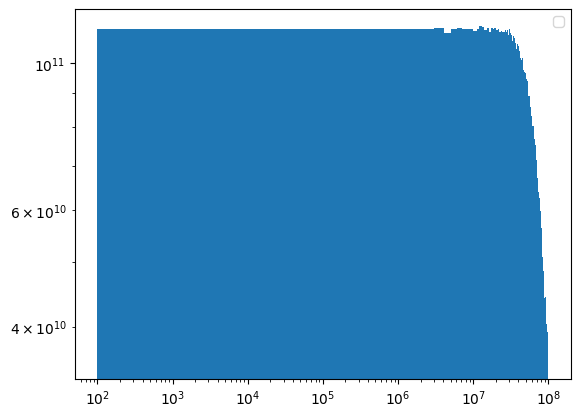

In [30]:
fig, ax = plt.subplots()
h = ax.hist(reco_energy, bins=np.linspace(1e2, 1e8, 100), weights=baseline_weights)
plt.legend()
plt.loglog()


In [31]:
config = "./test.yaml"

In [32]:
ana = pyFF.config.analysis_from_config(config)
params, priors = pyFF.config.params_from_config(config)

In [33]:
obs, ssq = ana.evaluate(data,params)

In [34]:
cobs, cssq = ana.evaluate_per_component(data,params)

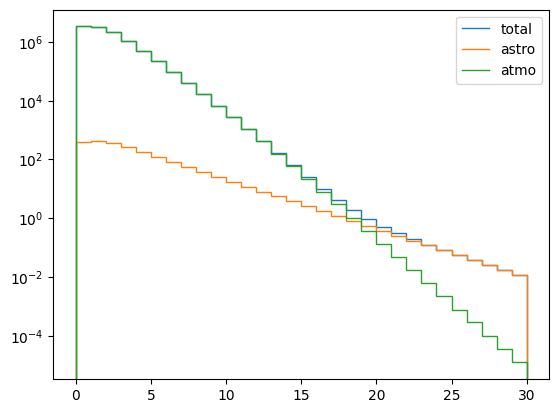

In [35]:
plt.stairs(obs["det1"].sum(axis=1),label="total")
plt.stairs(cobs["det1"]["astro"].sum(axis=1),label="astro")
plt.stairs(cobs["det1"]["atmo"].sum(axis=1),label="atmo")
plt.legend()
plt.yscale("log")

In [36]:
llh = pyFF.likelihood.PoissonLikelihood(ana,priors)
mini = pyFF.minimizer.ScipyMinimizer(llh)

In [37]:
mini.minimize(obs,data)

(  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 1663.6568047521996
         x: [ 2.000e+00  1.440e+00  1.000e+00]
       nit: 1
       jac: [ 1.178e-06  1.412e-07  1.096e-03]
      nfev: 6
      njev: 6
  hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>,
 {'astro_index': np.float64(2.0000000000001266),
  'astro_norm': np.float64(1.4400000000000144),
  'atmo_norm': np.float64(1.0000000001043308)},
 1663.6568047521996)

In [38]:
norms = np.linspace(0,3,11)
llhs = []
for norm in norms:
    res = mini.minimize(obs,data,fixed_pars={"astro_norm":norm})
    llhs.append(res[2])
llhs = np.asarray(llhs)

In [39]:
dllhs = 2*(llhs-np.min(llhs))

Text(0, 0.5, '-2DeltaLLH')

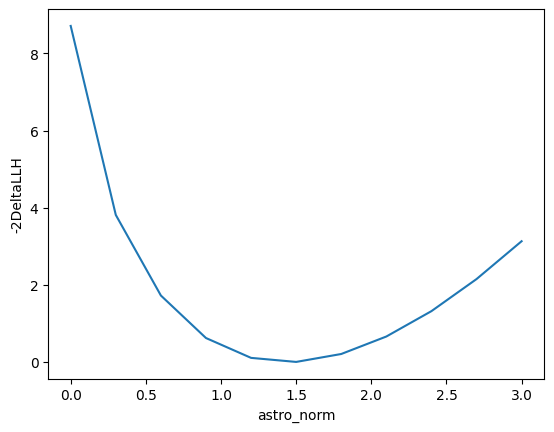

In [40]:
plt.plot(norms,dllhs)
plt.xlabel("astro_norm")
plt.ylabel("-2DeltaLLH")